In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import Optional, Literal
from pydantic import BaseModel

In [16]:
class QuadaticState(BaseModel):
    a: int 
    b: int 
    c: int 

    equation: str = None
    discriminant: float = None
    result: str = None

In [17]:
def show_equation(state: QuadaticState):

    equation = f'{state.a}x^2 + {state.b}x + {state.c}'

    return {'equation': equation}

def calculate_discriminant(state: QuadaticState):

    discriminant = (state.a)**2 - 4*(state.b)*(state.c)

    return {'discriminant': discriminant}

In [18]:
def real_roots(state: QuadaticState):
    a = state.a 
    b = state.b 
    c = state.c 

    root1 = (-1*b + (b**2 - 4*a*c)**0.5)/2*a
    root2 = (-1*b + (b**2 - 4*a*c)**0.5)/2*a

    result = f'There are two roots {root1} and {root2}'

    return {'result': result}


def equal_roots(state: QuadaticState):
    a = state.a 
    b = state.b 
    c = state.c 

    root1 = (-1*b)/2*a
    
    result = f'Only one root {root1}'

    return {'result': result}


def no_real_roots(state: QuadaticState):
    result = 'No real roots'

    return {'result': result}

In [19]:
def check_condition(state: QuadaticState) -> Literal["real_roots", "equal_roots", "no_real_roots"]:
    if state.discriminant > 0:
        return "real_roots"
    elif state.discriminant < 0:
        return "no_real_roots"
    else:
        return "equal_roots"

In [20]:
def passs(state: QuadaticState):
    return {}

In [ ]:
graph = StateGraph(QuadaticState)
graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('equal_roots', equal_roots)
graph.add_node('no_real_roots', no_real_roots)
graph.add_node('check_condition', check_condition)
graph.add_node('passs', passs)


graph.add_edge(START, 'show_equation')
graph.add_edge(START, 'calculate_discriminant')


graph.add_edge('show_equation', 'passs')
graph.add_edge('calculate_discriminant', 'passs')

graph.add_edge('calculate_discriminant', 'passs')
graph.add_edge('calculate_discriminant', 'passs')
graph.add_edge('calculate_discriminant', 'passs')

graph.add_conditional_edges('check_condition', check_condition)

graph.add_edge('real_roots', END)
graph.add_edge('equal_roots', END)
graph.add_edge('no_real_roots', END)


workflow = graph.compile()

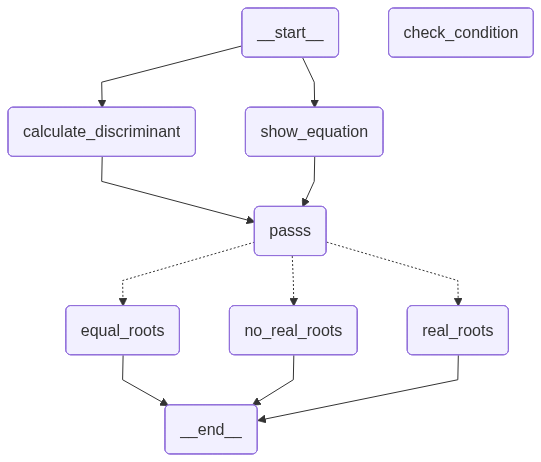

In [22]:
workflow

In [23]:
result = workflow.invoke({'a':1, 'b':2, 'c':3})
result

{'a': 1,
 'b': 2,
 'c': 3,
 'equation': '1x^2 + 2x + 3',
 'discriminant': -23,
 'result': 'No real roots'}